In [1]:
from src.backend import TorchBackend, Backend
from src.geometry import Rectangle, Bitmap, Lattice, VectorObject, Ellipse
from src.layer import Layer
from src.material import Material
from src.tvf import TVF
from src.source import Source
from src.sim import LayerSolver
from src.config import LayerConfig

import torch
import matplotlib.pyplot as plt
from typing import Any

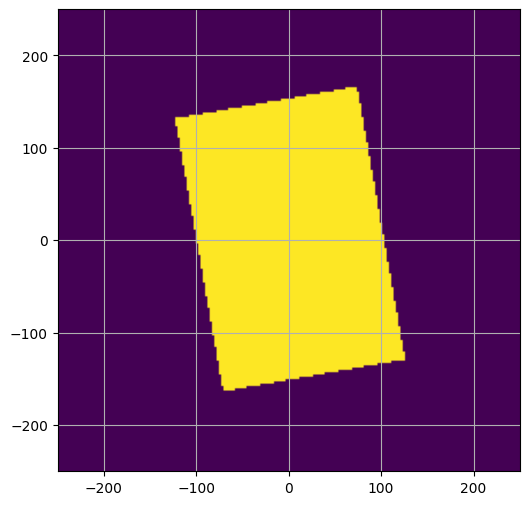

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
backend = TorchBackend(device=device, dtype=dtype)

period = (500, 500)
grid = (201, 201)
lattice = Lattice(period=period, grid=grid)

center = (0, 0)
size = (200, 300)
angle = 10.0*torch.pi/180

epsilon = [4.0, 2.0]
epsilon_bg = [1.3, 2.2]

mat = Material(backend, epsilon=epsilon)
mat_bg = Material(backend, epsilon=epsilon_bg)

shape = Rectangle(backend, lattice, center=center, size=size, material=mat, angle=angle, soft_mask=False)
layer = Layer(shape, thickness=500, material_bg=mat_bg)

wavelength = [500, 700.0]
theta = [0.0]
phi = [0.0]
source = Source(backend, wavelength=wavelength, theta=theta, phi=phi)

cfg = LayerConfig(M = 11, N = 11, closed_form=True, factorization='Pol', tvf_optimizer='LBFGS',
                  tvf_alpha=1.0, tvf_beta=1.0e-6, tvf_gamma=0.0, tvf_steps=1)

solver = LayerSolver(layer, source, cfg)

epsilon_xy = layer.epsilon_xy()[:,0,0,:,:]


plt.figure(figsize=(6,6))
plt.imshow(epsilon_xy[0].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.grid()

In [3]:
Delta_Pxx, Delta_Pyy, Delta_Pxy, Delta_Pyx = solver.correction_term()

   WARNING batched routines are designed for small sizes. It might be better to use the
   Native/Hybrid classical routines if you want good performance.
   WARNING batched routines are designed for small sizes. It might be better to use the
   Native/Hybrid classical routines if you want good performance.
   WARNING batched routines are designed for small sizes. It might be better to use the
   Native/Hybrid classical routines if you want good performance.
   WARNING batched routines are designed for small sizes. It might be better to use the
   Native/Hybrid classical routines if you want good performance.


In [5]:
Delta_Pxy.shape

torch.Size([2, 6889, 6889])

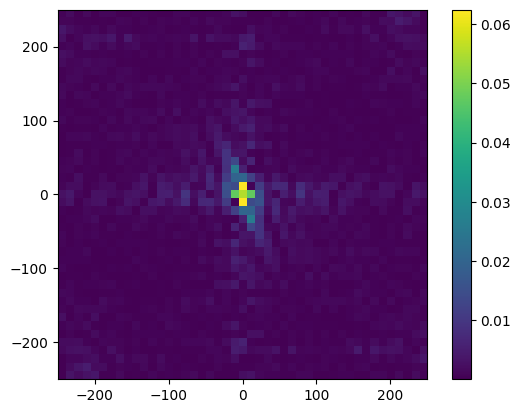

In [4]:
plt.imshow(Pxy[0].cpu().abs().T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.colorbar()

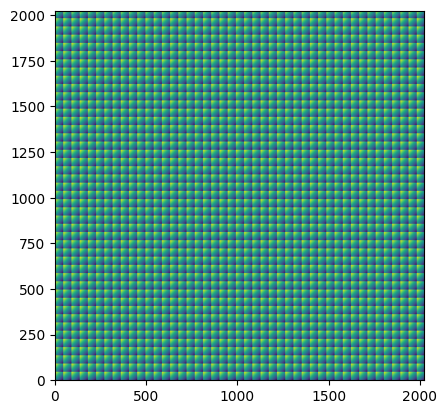

In [5]:
plt.imshow(solver.index_map[1].cpu(), origin='lower')